In [1]:
import matplotlib
matplotlib.use("Agg")
import plotly.io as pio
pio.renderers.default = "png"

# Theory-based inference

Alongside the simulation grammar, `moderndive` ships tidy wrappers for the
classical (formula-based) tests and a way to draw the theoretical distributions —
mirroring R `infer`'s `t_test`, `prop_test`, `chisq_test`, and `assume()`.

## One-line tests

In [2]:
import moderndive as md
from moderndive import t_test, prop_test, chisq_test

# One-sample t-test
age = md.load_age_at_marriage()
t_test(age, response="age", mu=23)
# → statistic, t_df, p_value, alternative, estimate, lower_ci, upper_ci

# Two-sample (Welch) t-test
movies = md.load_movies_sample()
t_test(movies, formula="rating ~ genre", order=("Action", "Romance"))

# Two-proportion z-test
yawn = md.load_mythbusters_yawn()
prop_test(yawn, formula="yawn ~ group", success="yes", order=("seed", "control"))

# Chi-squared test of independence
chisq_test(yawn, formula="yawn ~ group")
# → statistic, chisq_df, p_value

statistic,chisq_df,p_value
f64,i64,f64
0.105042,1,0.745861


`t_stat` and `chisq_stat` return just the test statistic if that's all you need.

## Theoretical distributions with `assume()`

`assume()` defines a theoretical sampling distribution you can visualize and use
for p-values without simulating:

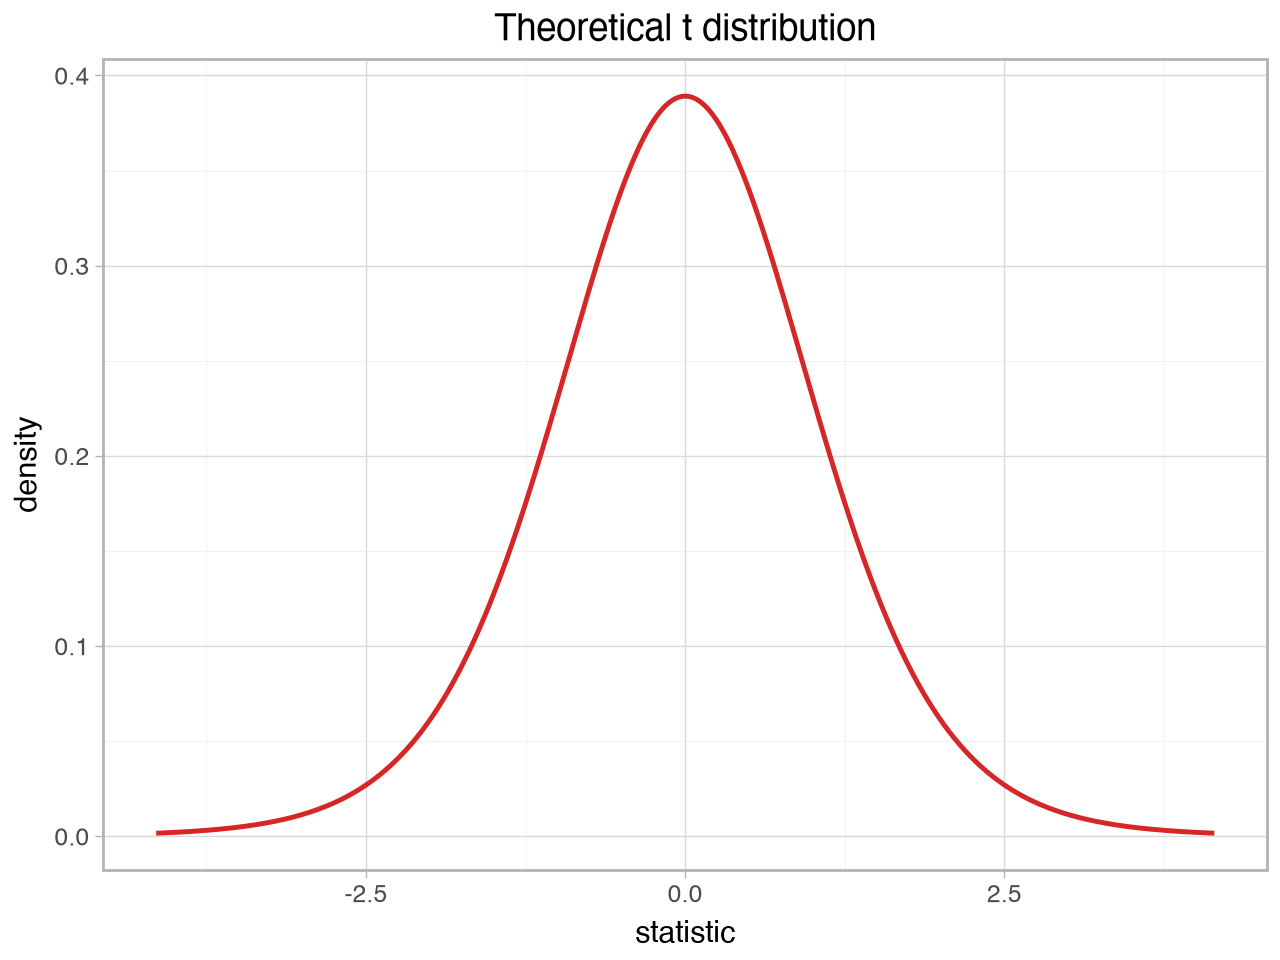

In [3]:
from moderndive import assume

# t-distribution with 10 degrees of freedom
t_dist = assume("t", df=10)
t_dist.get_p_value(2.0, direction="right")     # one-sided p-value

# plotly by default; engine="plotnine" for ggplot output
t_dist.visualize()
t_dist.visualize(engine="plotnine")

Supported distributions: `"t"`, `"z"`, `"F"` (pass `df=(df1, df2)`), and
`"Chisq"`.

## Overlaying theory on a simulation

`visualize(..., method=...)` can show the simulation histogram, the theoretical
curve, or both:

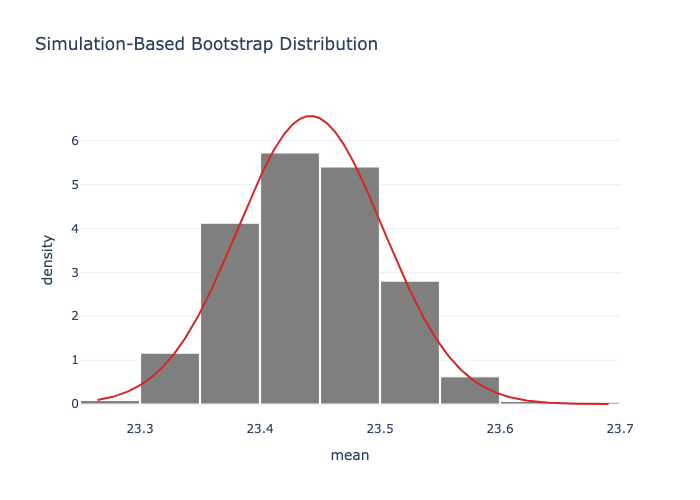

In [4]:
from moderndive import visualize

boot = (
    age.specify(response="age")
    .generate(reps=1000, type="bootstrap", seed=1)
    .calculate(stat="mean")
)

visualize(boot, method="both")          # histogram + normal-approximation curve

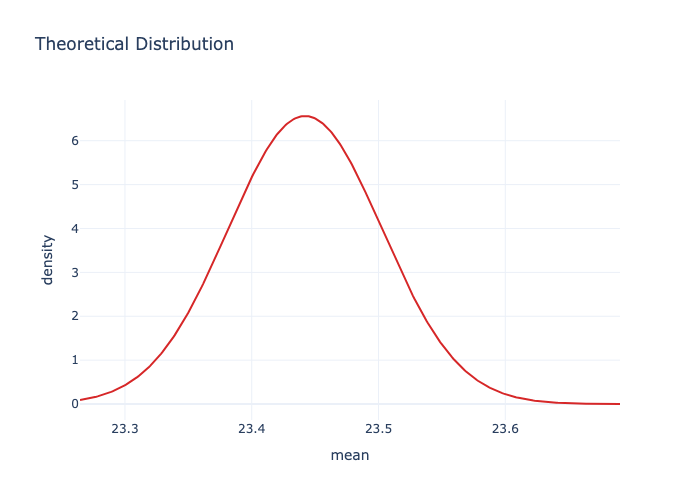

In [5]:
visualize(boot, method="theoretical")   # just the curve

## Population standard deviation

A small helper that divides by `n` (not `n − 1`):

In [6]:
from moderndive import pop_sd

pop_sd([1, 2, 3, 4, 5])   # → 1.414…

1.4142135623730951